In [1]:
# Import project modules from parent directories
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
for p in (cwd, cwd.parent, cwd.parent.parent):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

from VisualizeVF import VisualizeVF
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from Units2D import Units2D
from RabiLondon2D import RabiLondon2D
from scipy.optimize import curve_fit

def figuregen(rabilondon, rabioutput, A_sol,vis,t_grid,rabi_freq,lpfitmin,lpfitmax,tol):
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 24,
    })

    # Create three plots side-by-side with dynamic middle-column width
    x_p1_tmp, y_p1_tmp, _ = vis._p1_plot_triangulation()
    x_span = float(np.max(x_p1_tmp) - np.min(x_p1_tmp))
    y_span = float(np.max(y_p1_tmp) - np.min(y_p1_tmp))

    mid_ratio = (x_span / y_span) if y_span > 0 else 1.0
    mid_ratio = float(np.clip(mid_ratio, 0.7, 2.0))  # optional stability clamp

    fig = plt.figure(figsize=(22, 6), constrained_layout=False)
    gs = fig.add_gridspec(1, 3, width_ratios=[1.0, mid_ratio, 1.0], wspace=0.25)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])


    '''
    Plot 1: Rabi Oscillations
    '''
    # Rabi Oscillations plot + fit state-1 population to (1 - cos(omega * t))/2
    skip = 10
    number_of_states = 5
    eigenvalues, eigenvectors = rabilondon.eigenvalues, rabilondon.eigenvectors
    populations = [[] for _ in range(number_of_states)]
    for i in range(0, len(rabioutput), skip):
        psi = rabioutput[i]
        psi /= jnp.linalg.norm(psi)

        for j in range(number_of_states):
            p_j = jnp.abs(jnp.vdot(eigenvectors[:, j], psi))**2
            populations[j].append(p_j)

    # Convert to arrays for fitting
    sample_t = np.asarray(t_grid[::skip], dtype=float)
    state1_pop = np.asarray(populations[1], dtype=float)


    # (1 - cos(omega * t)) / 2
    def rabi_model(t, omega):
        return 0.5 * (1.0 - np.cos(omega * t))

    # Initial guess from your previously computed rabi_freq
    omega0 = float(np.real(rabi_freq)) if np.ndim(rabi_freq) == 0 else float(np.real(rabi_freq[0]))

    try:
        popt, pcov = curve_fit(rabi_model, sample_t, state1_pop, p0=[max(omega0, 1e-12)], bounds=(0.0, np.inf))
        omega_fit = float(popt[0])
        omega_fit_std = float(np.sqrt(np.diag(pcov))[0]) if np.isfinite(pcov).all() else np.nan
        fit_vals = rabi_model(sample_t, omega_fit)
        rmse = float(np.sqrt(np.mean((state1_pop - fit_vals) ** 2)))

        print(f"Fitted omega: {omega_fit:.9g}")
        print(f"Omega std err: {omega_fit_std:.3g}")
        print(f"RMSE: {rmse:.3g}")
    except Exception as e:
        omega_fit = np.nan
        omega_fit_std = np.nan
        fit_vals = np.full_like(sample_t, np.nan)
        rmse = np.nan
        print("Fit failed:", e)

    predicted_population = 0.5 * (1.0 - np.cos(float(np.real(rabi_freq)) * sample_t))

    ax1.plot(sample_t, predicted_population, "-",color="blue", lw=2, label="Predicted") 
    ax1.plot(sample_t, state1_pop, "-", color="orange",ms=3, label="Numerical Simulation")
    if np.isfinite(omega_fit):
        ax1.plot(sample_t, fit_vals, "--", lw=2, color="red",label=f"Fitted Curve")

    ax1.set_xlabel("Time")
    ax1.set_ylabel(r"$|\langle 1 | \psi_M \rangle|^2$")
    # ax1.set_title("Probability of Measuring State 1 vs Time")

    ax1.legend(loc='upper right',fontsize=16)

    '''
    Plot 2: Meissner Screening
    '''
    vis.visualize_vf(None, ax2, bz_symmetric_percentile=99.0)
    # APS-style cleanup: keep frame, but remove extra internal padding around data.
    x2, y2, _ = vis._p1_plot_triangulation()
    ax2.set_xlim(np.min(x2), np.max(x2))
    ax2.set_ylim(np.min(y2), np.max(y2))
    ax2.margins(0)

    '''
    Plot 3: London Penetration Depth
    '''

    def london_penetration_fit(A_sol,ax,xmin=-20,xmax=-15,tol=1):
        # 1D cross-section of magnetic field Bz using ONLY mesh nodes at y = 0
        # Run this after the cell that computes A_sol and creates `vis`.
        B_nodes = np.asarray(vis._project_bz_to_nodes()).ravel()
        x_p1, y_p1, _ = vis._p1_plot_triangulation()

        # Floating-point-safe selection of nodes exactly on y = 0
        mask = np.isclose(y_p1, 0.0, atol=tol)

        if not np.any(mask):
            raise ValueError(
                "No mesh nodes found at y=0. "
                "Try refining mesh or use a small |y| cutoff for an approximate section."
            )

        x_plot = np.asarray(x_p1[mask]).ravel()
        bz_plot = np.asarray(B_nodes[mask]).ravel()

        # Sort left-to-right for plotting
        order = np.argsort(x_plot)
        x_plot = x_plot[order]
        bz_plot = bz_plot[order]

        # Filter to only values where x in [-20, -12]
        mask_range = (x_plot >= xmin) & (x_plot <= xmax)
        x_plot = x_plot[mask_range]
        bz_plot = bz_plot[mask_range]

        from scipy.optimize import curve_fit

        # Define exponential decay model: A * exp(-x/tau) + C
        def exp_decay(x, A, tau, C):
            return A * np.exp(-x / tau) + C

        # Plot data and fit exponential decay

        # Initial guesses for parameters: amplitude, decay constant, offset
        A0 = bz_plot.max() - bz_plot.min()
        tau0 = (x_plot.max() - x_plot.min()) / 2
        C0 = bz_plot.min()

        try:
            popt, pcov = curve_fit(exp_decay, x_plot, bz_plot, p0=[A0, tau0, C0])
            A_opt, tau_opt, C_opt = popt
            print(f"Fit parameters: A = {A_opt:.3g}, tau = {tau_opt:.3g}, C = {C_opt:.3g}")
        except RuntimeError as e:
            print("Fit did not converge:", e)
            popt = None

        # Plot the data
        ax.plot(x_plot, bz_plot, "o", color="black", ms=4, lw=1.5) #, label=r"Data: $B_z$ at mesh nodes with $y=0$")
        ax.axhline(0.0, color="gray", linestyle="--", lw=1)

        # Plot the exponential decay fit, if available
        if popt is not None:
            x_fit = np.linspace(x_plot.min(), x_plot.max(), 200)
            bz_fit = exp_decay(x_fit, *popt)
            ax.plot(x_fit, bz_fit, 'r--', lw=2, label=r"Exp. decay: $A e^{-x/\tau} + C$")

        ax.set_xlabel(r"$x/\xi$")
        ax.set_ylabel(r"$B_z$ $[B_0]$")
        # ax.set_title(r"1D Magnetic Field Cross-Section (Fit to Exponential Decay, $y=0$)")
        ax.grid(alpha=0.3)
        # ax.legend()

    london_penetration_fit(A_sol,ax3,lpfitmin,lpfitmax,tol=tol)

    # Avoid collision with panel-2 colorbar text.
    ax3.yaxis.set_label_position("right")
    ax3.yaxis.tick_right()
    ax3.tick_params(axis="y", pad=4)

    # Panel labels
    for ax, lab in zip([ax1, ax2, ax3], ["(a)", "(b)", "(c)"]):
        ax.text(
            0.02, 0.98, lab,
            transform=ax.transAxes,
            ha="left", va="top",
            fontweight="bold",
            fontsize=32,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.2),
        )

    fig.subplots_adjust(left=0.05, right=0.98, bottom=0.18, top=0.95, wspace=0.12)

Fitted omega: 1.46537243e-05
Omega std err: 1.57e-08
RMSE: 0.0897
Fit parameters: A = 5.07e-09, tau = 3.55, C = -3.72e-05


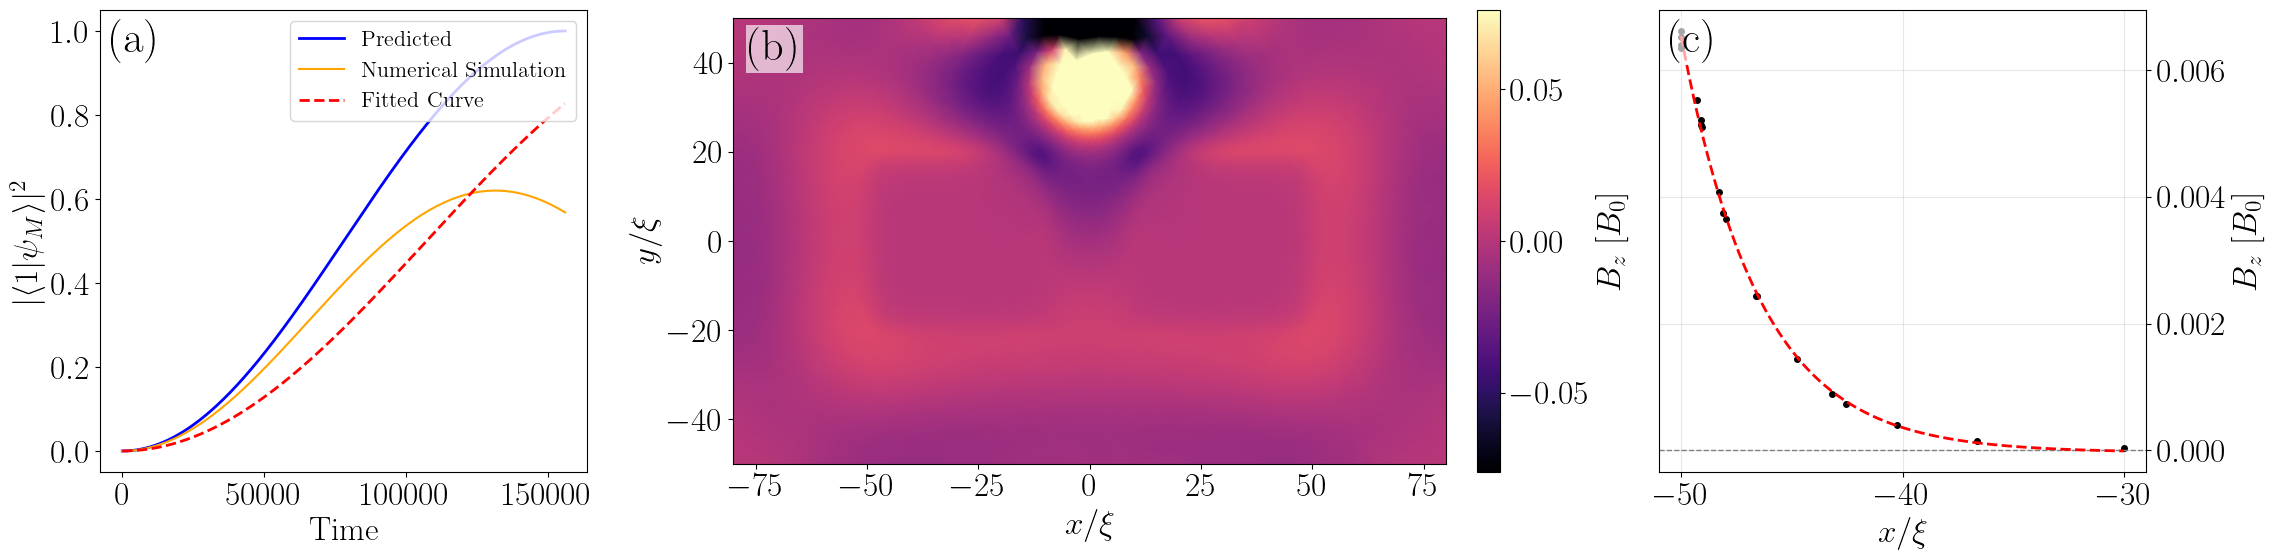

: 

In [ ]:
pickled_obj = {}
with open('./../allplots/testrun3.pkl', 'rb') as f:
    pickled_obj = pickle.load(f)

rabioutput = pickled_obj["rabioutput"]
t_grid = pickled_obj["t_grid"]
A_sol = pickled_obj["A_sol"]
rabilondon = pickled_obj["rabilondon"]
basis_edge = pickled_obj["basis_edge"]
rabi_freq = pickled_obj["rabi_freq"]
vis = VisualizeVF(rabilondon.mesh, basis_edge, A_sol)


figuregen(rabilondon, rabioutput, A_sol,vis,t_grid,rabi_freq,-50,-30,2)

Fitted omega: 1.75886668e-05
Omega std err: 4.47e-09
RMSE: 0.012
Fit parameters: A = 5.07e-09, tau = 3.55, C = -3.72e-05


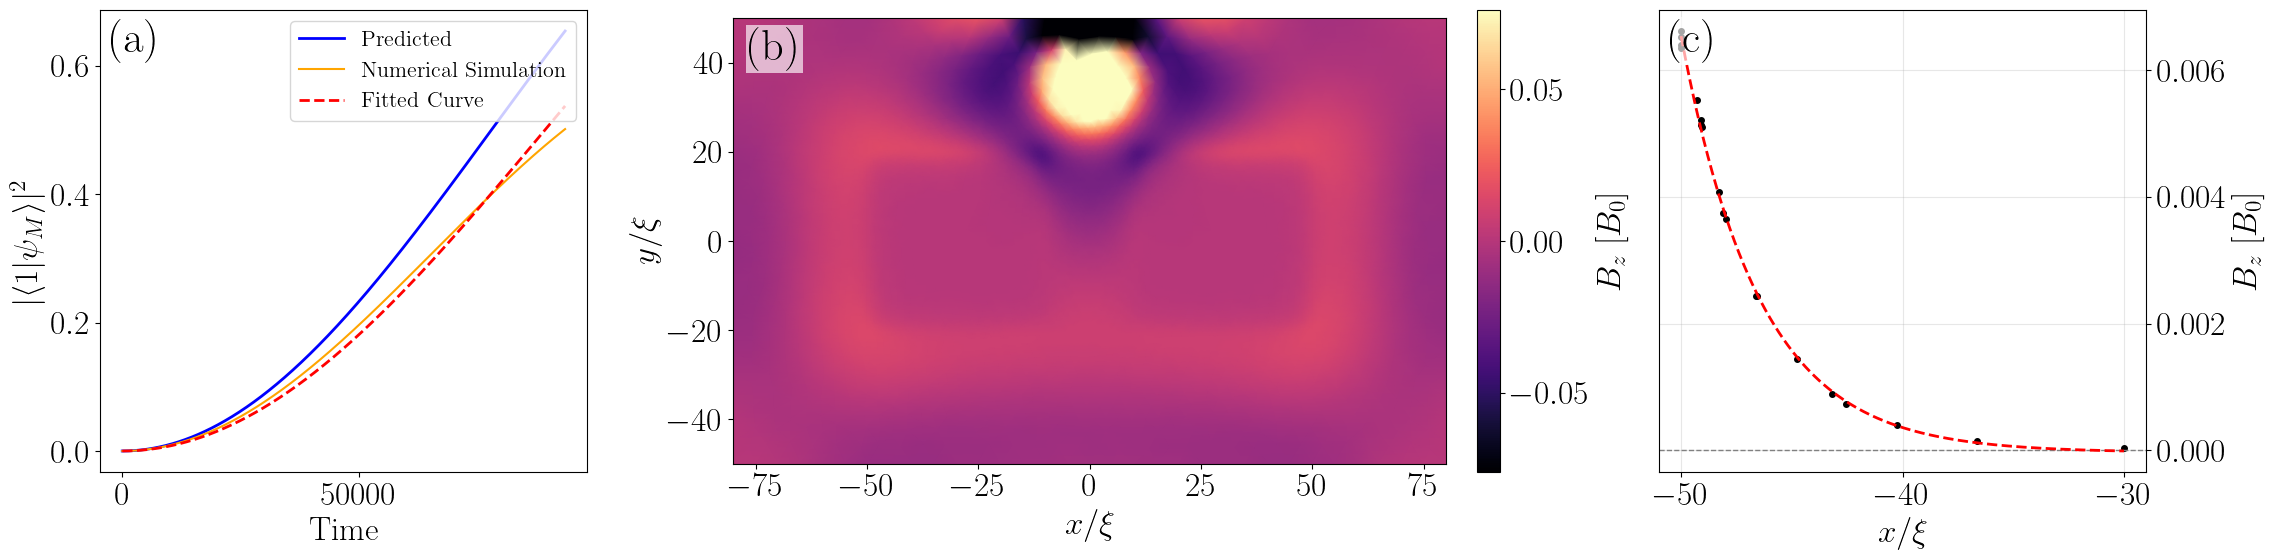

: 